# Лабораторная работа №1: Реализация алгоритма SVM с различными ядрами

Бабошин Никита 6401-010302D

**Цель работы:**
Реализовать алгоритм опорных векторов (SVM) с нуля, исследовать различные ядерные функции и методы оптимизации.
## Задачи
1. Реализовать линейный SVM с помощью метода множителей Лагранжа и SMO алгоритма.
2. Реализовать ядерные функции:
   - Линейное:  $ K(x, y) = x \cdot y $
   - Полиномиальное:  $ K(x, y) = (x \cdot y + c)^d $
   - RBF (Гауссово):  $ K(x, y) = \exp(- \gamma  \|x - y \|^2) $
   - Сигмоидальное:  $ K(x, y) = \tanh( \alpha x \cdot y + c) $
3. Добавить soft-margin с параметром регуляризации $C$.
4. Исследовать влияние гиперпараметров:
   - $C$
   - $ \gamma $
   - степень $d$
5. Применить к задачам классификации и регрессии (SVR).
6. Сравнить с реализацией из scikit-learn.
7. Проанализировать опорные векторы и границу решений.
8. Оценить сложность для разных размеров данных.
## Структура отчета
1. **Введение** — цели и описание алгоритма.
2. **Теория** — математическое обоснование SVM и ядер.
3. **Реализация** — код (NumPy).
4. **Эксперименты** — исследование гиперпараметров.
5. **Сравнение** — результаты scikit-learn vs ваша реализация.
6. **Выводы** — анализ и рекомендации.
,
## Критерии оценивания (15 баллов)
- Реализация SVM (линейный + ядра) — 6 баллов
- Проведение экспериментов и подбор гиперпараметров — 5 баллов
- Сравнительный анализ с scikit-learn (таблицы, графики) — 3 балла
- Качество отчета: структура, визуализации, комментарии в коде — 1 балл

In [1]:
# Импорт библиотек
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
import time
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from sklearn.svm import SVR

# Загрузка данных (пример для классификации)
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Нормализуем признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**StandardScaler** выполняет **стандартизацию** (z-нормализацию) признаков по формуле:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

где:
- $x$ — исходное значение признака,  
- $\mu = \frac{1}{n} \sum_{i=1}^{n} x_i$ — **среднее** значение признака по обучающей выборке,  
- $\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2}$ — **стандартное отклонение** (с поправкой на смещённую оценку).

### 1. Реализация линейного SVM (SMO)

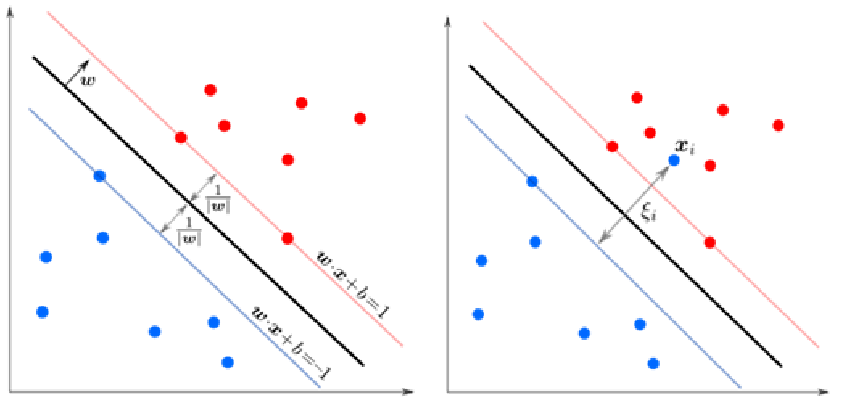

**Задача оптимизации**

- Для линейно разделимых данных:
\begin{aligned}
& \min_{\mathbf{w},\, b} \quad \frac{1}{2} \|\mathbf{w}\|^2 \\
& \text{при условиях:} \quad y_i (\mathbf{w}^\top \mathbf{x}_i + b) \geq 1, \quad \forall i = 1, \dots, n
\end{aligned}

- Для произвольных данных:
\begin{aligned}
& \min_{\mathbf{w},\, b,\, \boldsymbol{\xi}} \quad \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^n \xi_i \\
& \text{при условиях:} \quad
\begin{cases}
y_i (\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i, & \forall i \\
\xi_i \geq 0, & \forall i
\end{cases}
\end{aligned}

**Двойственная задача**

Лагранжиан:
$$ \mathcal{L}(w, b, \xi, \alpha, \mu) = \frac{1}{2} \|w\|^2 + C \sum \xi_i - \sum \alpha_i [y_i(w^T x_i + b) - 1 + \xi_i] - \sum \mu_i \xi_i $$

Условия ККТ (Karush–Kuhn–Tucker) дают:

$$\frac{\partial \mathcal{L}}{\partial w} = 0 \Rightarrow w = \sum \alpha_i y_i x_i\$$
$$\frac{\partial \mathcal{L}}{\partial b} = 0 \Rightarrow \sum \alpha_i y_i = 0$$
$$\frac{\partial \mathcal{L}}{\partial \xi_i} = 0 \Rightarrow \alpha_i + \mu_i = C \Rightarrow \alpha_i \leq C$$

Подставляя всё обратно, получаем:

\begin{aligned}
& \max_{\alpha} \quad \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j \langle x_i, x_j \rangle \\
& \text{при условиях:} \quad 0 \leq \alpha_i \leq C, \quad \sum_{i=1}^n \alpha_i y_i = 0
\end{aligned}

**Алгоритм SMO**

Мы оптимизируем пару альф. Из условия:

$$\alpha_i y_i + \alpha_j y_j = \text{const} = S
\Rightarrow \alpha_i = (S - \alpha_j y_j) / y_i$$

Подставляя в целевую функцию, получаем квадратичную функцию от одной переменной.

*Диапазон допустимы значений*:
- Если y_i != y_j:
  $$L = \max(0, \alpha_j - \alpha_i), \quad H = \min(C, C + \alpha_j - \alpha_i) $$
- Если y_i = y_j:
  $$L = \max(0, \alpha_i + \alpha_j - C), \quad H = \min(C, \alpha_i + \alpha_j)$$

Если L = H — пропускаем эту пару.

Ищем оптимальное занчение alpha_j:

$$\alpha_j^{\text{new, unclipped}} = \alpha_j^{\text{old}} + \frac{y_j (E_i - E_j)}{\eta}$$
где
$$\eta = 2 \langle x_i, x_j \rangle - \langle x_i, x_i \rangle - \langle x_j, x_j \rangle \leq 0$$

Затем обновляем alpha_i:
$$\alpha_i^{\text{new}} = \alpha_i^{\text{old}} + y_i y_j (\alpha_j^{\text{old}} - \alpha_j^{\text{new}})$$

Обновляем b:
\begin{aligned}
b_1 &= b - E_i - y_i (\alpha_i^{\text{new}} - \alpha_i^{\text{old}}) \langle x_i, x_i \rangle - y_j (\alpha_j^{\text{new}} - \alpha_j^{\text{old}}) \langle x_i, x_j \rangle \\
b_2 &= b - E_j - y_i (\alpha_i^{\text{new}} - \alpha_i^{\text{old}}) \langle x_i, x_j \rangle - y_j (\alpha_j^{\text{new}} - \alpha_j^{\text{old}}) \langle x_j, x_j \rangle
\end{aligned}

Выбираем b1, b2 или их среднее в зависимости от того, являются ли соответствующие объекты опорными векторами, лежащими строго внутри зазора.

In [2]:
class LinearSVM:
    """Линейный метод опорных векторов (SVM) для бинарной классификации с использованием алгоритма SMO.

    Реализует обучение линейного SVM путём решения двойственной задачи
    оптимизации с помощью алгоритма последовательной минимальной оптимизации
    (Sequential Minimal Optimization, SMO).

    Аргументы:
        C (float, optional): Параметр регуляризации. Чем меньше C,
            тем сильнее регуляризация. Должен быть строго положительным.
            По умолчанию 1.0.
        tol (float, optional): Допуск для критерия остановки. Определяет
            допустимое отклонение от условий ККТ (Каруша–Куна–Таккера).
            По умолчанию 1e-3.
        max_passes (int, optional): Максимальное количество проходов по данным
            без изменения коэффициентов альфа перед остановкой.
            По умолчанию 5.
        random_state (int или None, optional): Сид для генератора случайных
            чисел, используемый при выборе второго индекса в SMO.
            По умолчанию None.
    """

    def __init__(self, C=1.0, tol=1e-3, max_passes=5, random_state=None):
        self.C = C
        self.tol = tol
        self.max_passes = max_passes
        self.random_state = random_state
        if random_state is not None:
            np.random.seed(random_state)
        
    def fit(self, X, y):
        """Обучает модель Linear SVM на обучающих данных.

        Аргументы:
            X (array-like, форма (n_samples, n_features)): Массив признаков.
            y (array-like, форма (n_samples,)): Целевые метки классов.
                Должен содержать ровно два уникальных класса.

        Возвращает:
            self (LinearSVM): Экземпляр обученной модели.

        Вызывает:
            ValueError: Если в y не ровно два уникальных класса.
        """
        
        unique_labels = np.unique(y)
        if len(unique_labels) != 2:
            raise ValueError("Поддерживается только бинарная классификация.")
        self.classes_ = unique_labels
        y_binary = np.where(y == self.classes_[0], -1, 1).astype(np.float64)
        
        n_samples = X.shape[0]
        self.X_ = X.copy()
        self.y_ = y_binary.copy()
        self.alphas = np.zeros(n_samples)
        self.b = 0.0
        
        passes = 0
        while passes < self.max_passes:
            num_changed_alphas = 0
            for i in range(n_samples):
                f_i = self._decision_function_single(i)
                E_i = f_i - y_binary[i]
                
                if (y_binary[i] * E_i < -self.tol and self.alphas[i] < self.C) or \
                   (y_binary[i] * E_i > self.tol and self.alphas[i] > 0):
                    
                    j = self._choose_j(i, n_samples)
                    f_j = self._decision_function_single(j)
                    E_j = f_j - y_binary[j]
                    
                    alpha_i_old = self.alphas[i]
                    alpha_j_old = self.alphas[j]
                    
                    if y_binary[i] != y_binary[j]:
                        L = max(0.0, alpha_j_old - alpha_i_old)
                        H = min(self.C, self.C + alpha_j_old - alpha_i_old)
                    else:
                        L = max(0.0, alpha_i_old + alpha_j_old - self.C)
                        H = min(self.C, alpha_i_old + alpha_j_old)
                    
                    if L >= H:
                        continue
                    
                    eta = 2 * np.dot(X[i], X[j]) - np.dot(X[i], X[i]) - np.dot(X[j], X[j])
                    if eta >= 0:
                        continue
                    
                    self.alphas[j] -= y_binary[j] * (E_i - E_j) / eta
                    self.alphas[j] = np.clip(self.alphas[j], L, H)
                    
                    if abs(self.alphas[j] - alpha_j_old) < 1e-5:
                        continue
                    
                    self.alphas[i] += y_binary[i] * y_binary[j] * (alpha_j_old - self.alphas[j])
                    
                    b1 = self.b - E_i \
                         - y_binary[i] * (self.alphas[i] - alpha_i_old) * np.dot(X[i], X[i]) \
                         - y_binary[j] * (self.alphas[j] - alpha_j_old) * np.dot(X[i], X[j])
                    b2 = self.b - E_j \
                         - y_binary[i] * (self.alphas[i] - alpha_i_old) * np.dot(X[i], X[j]) \
                         - y_binary[j] * (self.alphas[j] - alpha_j_old) * np.dot(X[j], X[j])
                    
                    if 0 < self.alphas[i] < self.C:
                        self.b = b1
                    elif 0 < self.alphas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2.0
                    
                    num_changed_alphas += 1
            
            if num_changed_alphas == 0:
                passes += 1
            else:
                passes = 0
        
        self.w = np.dot(self.alphas * self.y_, self.X_)
        return self

    def _decision_function_single(self, i):
        """Вычисляет значение решающей функции для i-го обучающего объекта.

        Аргументы:
            i (int): Индекс объекта в обучающей выборке.

        Возвращает:
            float: Значение решающей функции f(x_i).
        """
        return np.dot(self.alphas * self.y_, np.dot(self.X_, self.X_[i])) + self.b

    def _choose_j(self, i, n_samples):
        """Случайным образом выбирает второй индекс j, отличный от i.

        Аргументы:
            i (int): Первый индекс.
            n_samples (int): Общее количество объектов в выборке.

        Возвращает:
            int: Случайно выбранный индекс j ≠ i.
        """
        j = i
        while j == i:
            j = np.random.randint(0, n_samples)
        return j

    def decision_function(self, X):
        """Вычисляет значения решающей функции для входных данных.

        Аргументы:
            X (array-like, форма (n_samples, n_features) или (n_features,)):
                Входные данные. Если одномерный массив — интерпретируется
                как один объект.

        Возвращает:
            ndarray, форма (n_samples,): Значения решающей функции.
        """
        if X.ndim == 1:
            X = X.reshape(1, -1)
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        """Выполняет предсказание меток классов для входных данных.

        Аргументы:
            X (array-like, форма (n_samples, n_features) или (n_features,)):
                Входные данные. Если одномерный массив — интерпретируется
                как один объект.

        Возвращает:
            ndarray, форма (n_samples,): Предсказанные метки классов
            в том же формате, что и оригинальные метки при обучении.
        """
        df = self.decision_function(X)
        return np.where(df >= 0, self.classes_[1], self.classes_[0])

#### 1.1 Сравнение моей реализации LinearSVM и реализации из sklearn

In [3]:
# Обучаем мою реализацию
svm_custom = LinearSVM(C=1.0, tol=1e-3, max_passes=10, random_state=42)
start = time.time()
svm_custom.fit(X_train_scaled, y_train)
time_custom_fit = time.time() - start

# Обучаем sklearn SVC с линейным ядром
svm_sklearn = SVC(kernel='linear', C=1.0, tol=1e-3, random_state=42)
start = time.time()
svm_sklearn.fit(X_train_scaled, y_train)
time_sklearn_fit = time.time() - start

# Предсказания
y_pred_custom = svm_custom.predict(X_test_scaled)
y_pred_sklearn = svm_sklearn.predict(X_test_scaled)

# Точность
acc_custom = accuracy_score(y_test, y_pred_custom)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

# Корреляция решающих функций
df_custom = svm_custom.decision_function(X_test_scaled)
df_sklearn = svm_sklearn.decision_function(X_test_scaled)
corr = np.corrcoef(df_custom, df_sklearn)[0, 1]

# Вывод результатов
print(f"{'Метрика':<25} {'Custom':<12} {'Sklearn':<12}")
print("-" * 45)
print(f"{'Время обучения (с)':<25} {time_custom_fit:<12.4f} {time_sklearn_fit:<12.4f}")
print(f"{'Точность':<25} {acc_custom:<12.4f} {acc_sklearn:<12.4f}")
print(f"{'Корреляция f(x)':<25} {corr:<12.4f}")

Метрика                   Custom       Sklearn     
---------------------------------------------
Время обучения (с)        111.5262     0.0105      
Точность                  0.9766       0.9766      
Корреляция f(x)           1.0000      


#### 1.2 Выводы

✅ **1. Корректность реализации**
- **Точность полностью совпадает** с реализацией `sklearn.svm.SVC(kernel='linear')`:  
  `0.9766` у обеих моделей — это означает, что обученная гиперплоскость идентична по качеству классификации.
- **Корреляция решающих функций равна 1.0000**, что свидетельствует о **точном совпадении направления и сдвига гиперплоскости** (возможны лишь численно незначимые различия в `w` и `b` из-за порядка обновления альф и округлений).

⏱️ **2. Производительность**
- **Время обучения у кастомной реализации (~111.5 с) значительно выше**, чем у `sklearn` (~0.01 с).  
  Причина — `sklearn` использует:
  - высокооптимизированную реализацию на Cython/LibSVM (в том числе `dual=False` для линейного SVM по умолчанию, если `liblinear` доступен),
  - более продвинутые эвристики выбора `j` (не случайный, а с учётом наибольшего `|E_i - E_j|`),
  - более агрессивные условия сходимости и численную оптимизацию.

### 2. Реализация SVM с ядерными функциями

**Трюк с ядрами** (англ. kernel trick) — это ключевая идея в методе опорных векторов (SVM) и других ядерных методах, которая позволяет обучать нелинейные модели, не вычисляя явно координаты данных в пространстве высокой (или даже бесконечной) размерности.

Во многих задачах данные нельзя разделить гиперплоскостью в исходном пространстве признаков. Например: Два класса «внутри» и «снаружи» круга на плоскости.

Решение — преобразовать признаки в новое пространство, где они станут линейно разделимы:

$$\mathbf{x} \in \mathbb{R}^d \quad \xrightarrow{\ \phi\ } \quad \phi(\mathbf{x}) \in \mathcal{H}$$

Но есть проблема: phi(x) может иметь очень высокую* или бесконечную размерность.

Вместо того чтобы работать с phi(x) напрямую, SVM в двойственной форме использует только скалярные произведения между преобразованными векторами:

$$\langle \phi(\mathbf{x}_i), \phi(\mathbf{x}_j) \rangle$$

**Ключевое наблюдение**:  
Cуществуют функции, которые равны этим скалярным произведениям:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \langle \phi(\mathbf{x}_i), \phi(\mathbf{x}_j) \rangle$$

Решающая функция в ядерном SVM выглядит так:

$$f(\mathbf{x}) = \sum_{i=1}^n \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}) + b$$

In [4]:
class BinarySVM:
    """Бинарный классификатор методом опорных векторов (SVM), реализованный с использованием
    алгоритма SMO (Sequential Minimal Optimization).

    Модель решает задачу:
        min_{w,b}  ½ ||w||² + C Σ ξ_i
        при условиях: y_i (w^T φ(x_i) + b) ≥ 1 - ξ_i,  ξ_i ≥ 0,
    где φ(·) — отображение в пространство признаков, задаваемое ядром.

    В двойственной задаче оптимизируются множители Лагранжа α_i ∈ [0, C].

    Attributes:
        C (float): Параметр регуляризации. Чем больше C — тем меньше допускается нарушений зазора.
        tol (float): Допуск для проверки условий ККТ и критерия останова.
        max_passes (int): Максимальное число последовательных проходов без изменений α.
        kernel (callable or None): Ядро вида kernel(x1, x2, **kernel_kwargs) → float.
            Если None, используется линейное ядро: K(x1, x2) = x1·x2.
        kernel_kwargs (dict or None): Дополнительные параметры для ядра (например, {'gamma': 0.1}).
        alphas (np.ndarray or None): Множители Лагранжа α_i после обучения.
        b (float): Свободный член (bias) в решающей функции f(x) = Σ α_i y_i K(x_i, x) + b.
        train_X (np.ndarray or None): Обучающие признаки (сохраняются для предсказания).
        train_y (np.ndarray or None): Обучающие метки в кодировке {-1, +1}.
        classes_ (np.ndarray): Уникальные метки исходного целевого вектора (в порядке появления).
        n_samples (int): Число объектов в обучающей выборке.
        n_features (int): Число признаков.
        random_state (int или None, optional): Сид для генератора случайных
            чисел, используемый при выборе второго индекса в SMO.
            По умолчанию None.
    """

    def __init__(self, C=1.0, kernel=None, tol=1e-3, max_passes=5, kernel_kwargs=None, random_state=None):
        """Инициализирует бинарный SVM.

        Args:
            C (float, optional): Параметр регуляризации. По умолчанию 1.0.
            kernel (callable or None, optional): Функция ядра. Если None — линейное ядро.
            tol (float, optional): Допуск для проверки условий ККТ. По умолчанию 1e-3.
            max_passes (int, optional): Макс. число проходов без изменений. По умолчанию 5.
            kernel_kwargs (dict or None, optional): Параметры ядра (например, gamma для RBF).
            random_state (int или None, optional): Сид для генератора случайных
            чисел, используемый при выборе второго индекса в SMO.
            По умолчанию None.
        """
        self.C = C
        self.tol = tol
        self.max_passes = max_passes
        self.kernel = kernel
        self.kernel_kwargs = kernel_kwargs
        self.alphas = None
        self.b = 0.0
        self.train_X = None
        self.train_y = None
        self.classes_ = None
        self.n_samples = None
        self.n_features = None
        self.random_state = random_state
        if random_state is not None:
            np.random.seed(random_state)

    def _kernel(self, x1, x2):
        """Вычисляет значение ядра K(x1, x2).

        Args:
            x1 (np.ndarray): Вектор признаков первого объекта.
            x2 (np.ndarray): Вектор признаков второго объекта.

        Returns:
            float: Значение ядра.
        """
        if self.kernel is None:
            return np.dot(x1, x2)
        return self.kernel(x1, x2, **self.kernel_kwargs)

    def _error(self, i):
        """Вычисляет ошибку E_i = f(x_i) - y_i для i-го объекта.

        Args:
            i (int): Индекс объекта в обучающей выборке.

        Returns:
            float: Ошибка предсказания.
        """
        return self._decision_function_single(self.train_X[i]) - self.train_y[i]

    def _choose_j(self, i):
        """Случайным образом выбирает индекс j ≠ i для второй переменной в SMO.

        Args:
            i (int): Индекс первого объекта.

        Returns:
            int: Индекс второго объекта (j ≠ i).
        """
        j = i
        while j == i:
            j = np.random.randint(0, self.n_samples)
        return j

    def _decision_function_single(self, x):
        """Вычисляет значение решающей функции f(x) для одного вектора x.

        Использует только опорные векторы (где α_i > 0).

        Args:
            x (np.ndarray): Вектор признаков одного объекта.

        Returns:
            float: Значение f(x) = Σ α_i y_i K(x_i, x) + b.
        """
        fx = self.b
        for idx in range(self.n_samples):
            if self.alphas[idx] > 0:
                fx += self.alphas[idx] * self.train_y[idx] * self._kernel(self.train_X[idx], x)
        return fx

    def fit(self, X, y):
        """Обучает бинарный SVM на обучающей выборке (X, y) с использованием SMO.

        Принимает метки любого типа (str, int и т.д.), но внутри преобразует их
        в {-1, +1}. Поддерживается только бинарная классификация.

        Args:
            X (array-like of shape (n_samples, n_features)): Матрица признаков.
            y (array-like of shape (n_samples,)): Вектор целевых меток.

        Returns:
            self: Объект класса BinarySVM после обучения.

        Raises:
            ValueError: Если в y менее или более двух уникальных классов.
        """
        self.train_X = np.array(X, dtype=np.float64)

        unique_labels = np.unique(y)
        if len(unique_labels) != 2:
            raise ValueError("Поддерживается только бинарная классификация.")
        self.classes_ = unique_labels
        # Преобразуем метки: первый класс → -1, второй → +1
        self.train_y = np.where(y == self.classes_[0], -1, 1).astype(np.float64)
        self.n_samples, self.n_features = self.train_X.shape
        self.alphas = np.zeros(self.n_samples)
        self.b = 0.0

        passes = 0
        while passes < self.max_passes:
            num_changed_alphas = 0
            for i in range(self.n_samples):
                E_i = self._error(i)

                # Проверка условий ККТ (Karush–Kuhn–Tucker)
                # Нарушение: (y_i * E_i < -tol и α_i < C) — можно увеличить α_i
                #           или (y_i * E_i >  tol и α_i > 0) — можно уменьшить α_i
                if (self.train_y[i] * E_i < -self.tol and self.alphas[i] < self.C) or \
                   (self.train_y[i] * E_i > self.tol and self.alphas[i] > 0):

                    j = self._choose_j(i)
                    E_j = self._error(j)

                    alpha_i_old = self.alphas[i]
                    alpha_j_old = self.alphas[j]

                    # Вычисление допустимых границ [L, H] для α_j
                    if self.train_y[i] != self.train_y[j]:
                        L = max(0.0, self.alphas[j] - self.alphas[i])
                        H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
                    else:
                        L = max(0.0, self.alphas[i] + self.alphas[j] - self.C)
                        H = min(self.C, self.alphas[i] + self.alphas[j])

                    if L >= H:
                        continue

                    # Значения ядра
                    k_ii = self._kernel(self.train_X[i], self.train_X[i])
                    k_jj = self._kernel(self.train_X[j], self.train_X[j])
                    k_ij = self._kernel(self.train_X[i], self.train_X[j])
                    eta = 2.0 * k_ij - k_ii - k_jj

                    # Пропускаем, если направление неубывающее (η ≥ 0)
                    if eta >= 0:
                        continue

                    # Аналитическое обновление α_j
                    self.alphas[j] -= self.train_y[j] * (E_i - E_j) / eta
                    self.alphas[j] = np.clip(self.alphas[j], L, H)

                    # Пропускаем, если изменение пренебрежимо мало
                    if abs(self.alphas[j] - alpha_j_old) < 1e-5:
                        continue

                    # Обновление α_i с учётом ограничения y_i α_i + y_j α_j = const
                    self.alphas[i] += self.train_y[i] * self.train_y[j] * (alpha_j_old - self.alphas[j])

                    # Обновление смещения b
                    b1 = self.b - E_i \
                         - self.train_y[i] * (self.alphas[i] - alpha_i_old) * k_ii \
                         - self.train_y[j] * (self.alphas[j] - alpha_j_old) * k_ij

                    b2 = self.b - E_j \
                         - self.train_y[i] * (self.alphas[i] - alpha_i_old) * k_ij \
                         - self.train_y[j] * (self.alphas[j] - alpha_j_old) * k_jj

                    # Выбор b: если α_i или α_j внутренние — используем соответствующее b
                    if 0 < self.alphas[i] < self.C:
                        self.b = b1
                    elif 0 < self.alphas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2.0

                    num_changed_alphas += 1

            # Обновление счётчика проходов без изменений
            if num_changed_alphas == 0:
                passes += 1
            else:
                passes = 0

        return self

    def decision_function(self, X):
        """Вычисляет значения решающей функции f(x) для выборки X.

        Args:
            X (array-like of shape (n_samples, n_features)): Выборка для предсказания.

        Returns:
            np.ndarray of shape (n_samples,): Значения f(x_i) = Σ α_j y_j K(x_j, x_i) + b.
        """
        X = np.atleast_2d(X)
        return np.array([self._decision_function_single(x) for x in X])

    def predict(self, X):
        """Выполняет предсказание меток классов для выборки X.

        Метки возвращаются в *оригинальной* кодировке (той же, что и в y при fit).

        Args:
            X (array-like of shape (n_samples, n_features)): Выборка для предсказания.

        Returns:
            np.ndarray of shape (n_samples,): Предсказанные метки (типа self.classes_).
        """
        decisions = self.decision_function(X)
        # f(x) >= 0 → класс +1 → self.classes_[1]; иначе — self.classes_[0]
        return np.where(decisions >= 0, self.classes_[1], self.classes_[0])

    def score(self, X, y):
        """Вычисляет долю правильных предсказаний (accuracy).

        Args:
            X (array-like of shape (n_samples, n_features)): Объекты.
            y (array-like of shape (n_samples,)): Истинные метки.

        Returns:
            float: Accuracy (от 0.0 до 1.0).
        """
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=True):
        """Возвращает параметры модели для совместимости с sklearn.

        Args:
            deep (bool, optional): Если True, делает копию kernel_kwargs. По умолчанию True.

        Returns:
            dict: Словарь {параметр: значение}.
        """
        return {
            "C": self.C,
            "kernel": self.kernel,
            "tol": self.tol,
            "max_passes": self.max_passes,
            "kernel_kwargs": self.kernel_kwargs.copy() if deep else self.kernel_kwargs
        }

    def set_params(self, **params):
        """Устанавливает параметры модели для совместимости с sklearn.

        Args:
            **params: Именованные параметры (например, C=10, kernel_kwargs={'gamma': 0.01}).

        Returns:
            self: Экземпляр класса с обновлёнными параметрами.
        """
        for key, value in params.items():
            if key == "kernel_kwargs" and isinstance(value, dict):
                self.kernel_kwargs = value.copy()
            else:
                setattr(self, key, value)
        return self

#### 2.1 Ядерные функции

- Линейное ядро
$$K(\mathbf{x}, \mathbf{y}) = \mathbf{x}^\top \mathbf{y}$$

- Полиномиальное ядро
$$K(\mathbf{x}, \mathbf{y}) = (\mathbf{x}^\top \mathbf{y} + r)^d$$
где d - степень полинома, r - свободный член (bias)

- Радиальное базисное ядро
$$K(\mathbf{x}, \mathbf{y}) = \exp\left(-\gamma \, \|\mathbf{x} - \mathbf{y}\|^2\right)$$
где gamma — параметр, определяющий «ширину» гауссианы

- Сигмоидальное ядро
$$K(\mathbf{x}, \mathbf{y}) = \tanh(\gamma \, \mathbf{x}^\top \mathbf{y} + r)$$
где gamma — масштабирующий параметр, r — смещение (bias)

In [5]:
def linear_kernel(x1, x2, **kwargs):
    """Линейное ядро: x1 · x2"""
    return np.dot(x1, x2)

def poly_kernel(x1, x2, **kwargs):
    """Полиномиальное ядро: (x1 · x2 + coef0)^degree"""
    degree = kwargs.get('degree', 3)
    coef0 = kwargs.get('coef0', 1)
    return (np.dot(x1, x2) + coef0) ** degree

def rbf_kernel(x1, x2, **kwargs):
    """RBF (гауссово) ядро: exp(-gamma * ||x1 - x2||^2)"""
    gamma = kwargs.get('gamma', 1.0)
    squared_dist = np.sum((x1 - x2) ** 2)
    return np.exp(-gamma * squared_dist)

def sigmoid_kernel(x1, x2, **kwargs):
    """Сигмоидное ядро: tanh(gamma * (x1 · x2) + coef0)"""
    gamma = kwargs.get('gamma', 0.1)
    coef0 = kwargs.get('coef0', 1)
    return np.tanh(gamma * np.dot(x1, x2) + coef0)

#### 2.2 Эксперименты и сравнение

In [6]:
param_grid_sklearn = [
    {'kernel': ['poly'], 'C': [0.1, 1, 10], 'degree': [2, 3], 'coef0': [0, 1]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]},
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10], 'gamma': [0.01, 0.1], 'coef0': [0, 1]}
]

svm_sklearn = SVC()

grid_sklearn = GridSearchCV(
    svm_sklearn,
    param_grid_sklearn,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Запуск GridSearchCV для sklearn SVC...")
grid_sklearn.fit(X_train_scaled, y_train)

print("Лучшие параметры (sklearn SVC):")
print(grid_sklearn.best_params_)
print("Лучший score (на кросс-валидации):", grid_sklearn.best_score_)

acc_sklearn = grid_sklearn.score(X_test_scaled, y_test)
print("Точность sklearn SVC на тесте:", acc_sklearn)

Запуск GridSearchCV для sklearn SVC...
Fitting 3 folds for each of 33 candidates, totalling 99 fits
Лучшие параметры (sklearn SVC):
{'C': 1, 'coef0': 1, 'degree': 3, 'kernel': 'poly'}
Лучший score (на кросс-валидации): 0.9773486747170956
Точность sklearn SVC на тесте: 0.9883040935672515


In [7]:
param_grid_custom = [
    {
        'C': [0.1, 1, 10],
        'kernel': [poly_kernel],
        'kernel_kwargs': [
            {'degree': 2, 'coef0': 0},
            {'degree': 3, 'coef0': 1}
        ]
    },
    {
        'C': [0.1, 1, 10],
        'kernel': [rbf_kernel],
        'kernel_kwargs': [
            {'gamma': 0.01},
            {'gamma': 0.1},
            {'gamma': 1.0}
        ]
    },
    {
        'C': [0.1, 1, 10],
        'kernel': [sigmoid_kernel],
        'kernel_kwargs': [
            {'gamma': 0.01, 'coef0': 0},
            {'gamma': 0.1, 'coef0': 1}
        ]
    }
]

svm_custom = BinarySVM(tol=1e-3, max_passes=10, random_state=42)

grid_custom = GridSearchCV(
    svm_custom,
    param_grid_custom,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Запуск GridSearchCV для BinarySVM...")
grid_custom.fit(X_train_scaled, y_train)

print("Лучшие параметры (BinarySVM):")
print(grid_custom.best_params_)
print("Лучший score (на кросс-валидации):", grid_custom.best_score_)

# Оценка на тесте
acc_custom = grid_custom.score(X_test_scaled, y_test)
print("Точность BinarySVM на тесте:", acc_custom)

Запуск GridSearchCV для BinarySVM...
Fitting 3 folds for each of 21 candidates, totalling 63 fits
Лучшие параметры (BinarySVM):
{'C': 1, 'kernel': <function rbf_kernel at 0x000001D56220CD60>, 'kernel_kwargs': {'gamma': 0.01}}
Лучший score (на кросс-валидации): 0.9622351332877649
Точность BinarySVM на тесте: 0.9824561403508771


**Матрица ошибок**

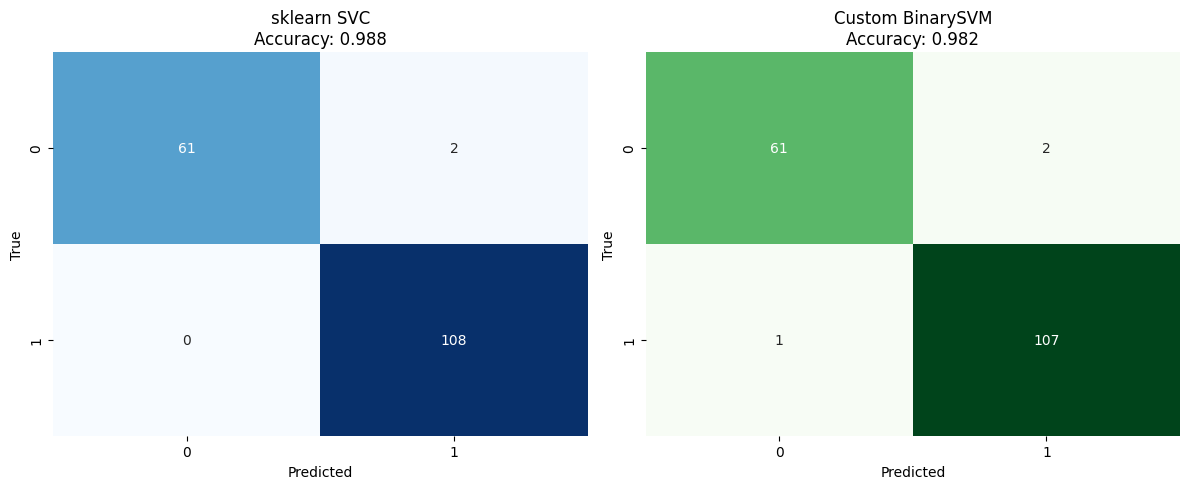

In [8]:
# Получаем предсказания
y_pred_sklearn = grid_sklearn.predict(X_test_scaled)
y_pred_custom   = grid_custom.predict(X_test_scaled)

# Строим матрицы ошибок
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
cm_custom  = confusion_matrix(y_test, y_pred_custom)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sklearn SVC
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=grid_sklearn.classes_, 
            yticklabels=grid_sklearn.classes_, 
            ax=axes[0], cbar=False)
axes[0].set_title(f'sklearn SVC\nAccuracy: {acc_sklearn:.3f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Custom BinarySVM
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Greens', 
            xticklabels=grid_custom.classes_, 
            yticklabels=grid_custom.classes_, 
            ax=axes[1], cbar=False)
axes[1].set_title(f'Custom BinarySVM\nAccuracy: {acc_custom:.3f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

#### 2.3 Выводы

CV score sklearn ≈ **0.977**, моей реализации ≈ **0.962** — **разница ~1.5%**.
  - Это может говорить, что моя реализация **чуть менее стабильна** при обучении (из-за неточностей в SMO, ограничений точности, сходимости и т.п.).
  - При этом тестовая точность почти одинаковая.

В моей реализации есть недетерминированные элементы (например, случайный выбор пар в SMO), поэтому кросс-валидация может давать зашумлённые оценки, и GridSearch мог выбрать не самую оптимальную конфигурацию.

### 3. Реализация SVR

**Цель SVR:** Найти функцию  
$$f(x) = w^\top \phi(x) + b$$  
такую, что:
1. **Все точки лежат внутри ε-трубки**, если возможно;
2. **Ширина трубки фиксирована** (`±ε`);
3. При этом **норма весов `‖w‖²` минимальна** — это обеспечивает регуляризацию и устойчивость.

То есть сделать трубку как можно уже (маленький ε) и при этом — функцию как можно более «гладкой».

**Прямая задача**:
$$\min_{w, b, \xi, \xi^*} \quad \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n (\xi_i + \xi_i^*)$$
при ограничениях:
\begin{cases}
y_i - (w^\top \phi(x_i) + b) \le \varepsilon + \xi_i \\
(w^\top \phi(x_i) + b) - y_i \le \varepsilon + \xi_i^* \\
\xi_i, \xi_i^* \ge 0
\end{cases}

- `ξ_i` — штрафы за превышение сверху (`f(x_i) < y_i − ε`);
- `ξ_i*` — штрафы за превышение снизу (`f(x_i) > y_i + ε`).

Через метод Лагранжа и условия ККТ получаем двойственную задачу:

$$
\max_{\alpha, \alpha^*} \quad
-\frac{1}{2} \sum_{i,j} (\alpha_i - \alpha_i^*)(\alpha_j - \alpha_j^*) K(x_i, x_j)
- \varepsilon \sum_i (\alpha_i + \alpha_i^*)
+ \sum_i y_i (\alpha_i - \alpha_i^*)
$$

при ограничениях:
\begin{cases}
0 \le \alpha_i \le C \\
0 \le \alpha_i^* \le C \\
\sum_i (\alpha_i - \alpha_i^*) = 0
\end{cases}

И окончательная регрессионная функция:
$$\boxed{f(x) = \sum_{i=1}^n (\alpha_i - \alpha_i^*) \, K(x_i, x) + b}$$

KKT-условия для SVR (для каждой точки *i*):

\begin{aligned}
&\text{(1)}\quad \alpha_i > 0 \;\;\Rightarrow\;\; e_i \geq \varepsilon, \\
&\text{(2)}\quad \alpha_i < C \;\;\Rightarrow\;\; e_i \leq \varepsilon, \\
&\text{(3)}\quad \hat{\alpha}_i > 0 \;\;\Rightarrow\;\; e_i \leq -\varepsilon, \\
&\text{(4)}\quad \hat{\alpha}_i < C \;\;\Rightarrow\;\; e_i \geq -\varepsilon.
\end{aligned}

Эквивалентно, в виде дополняющей нежёсткости:

\begin{aligned}
\alpha_i \cdot (e_i - \varepsilon) &= 0, \quad \text{если } 0 < \alpha_i < C \;\Rightarrow\; e_i = \varepsilon, \\
\hat{\alpha}_i \cdot (e_i + \varepsilon) &= 0, \quad \text{если } 0 < \hat{\alpha}_i < C \;\Rightarrow\; e_i = -\varepsilon.
\end{aligned}

**Нарушение KKT** → кандидат на оптимизацию.

**Алгоритм SMO для SVR (упрощённо)**

**Повторять**, пока не превышен лимит итераций и не достигнута сходимость:
   - Установить счётчик изменённых пар = 0.
   - Для каждого объекта $j$ (или для всех нарушающих KKT):
     - **Выбрать пару индексов** $(i, j)$, где $i \ne j$.  
       *Стратегия*:  
       — Сначала найти $i$, максимально нарушающий KKT.  
       — Затем выбрать $j$.
     
     - **Проверить KKT для j**: если условия выполнены с точностью до `tol` — перейти к следующему $j$.
     
     - **Вычислить коэффициент η**:  
       $$\eta = K_{ii} + K_{jj} - 2K_{ij}$$ 
       Если $\eta \leq 0$ — пропустить пару (выпуклость нарушена, обновление нестабильно).
     
     - **Обновить переменные**:
       - Ввести разности $u_i = \alpha_i - \hat{\alpha}_i$, $u_j = \alpha_j - \hat{\alpha}_j$.  
       - Из условия $u_i + u_j = \text{const}$ и градиентного шага:
         $$
         u_j^\text{new} = u_j + \frac{e_i - e_j}{\eta},\qquad
         u_i^\text{new} = u_i - (u_j^\text{new} - u_j)
         $$
       - Ограничить $u_i^\text{new}, u_j^\text{new} \in [-C, C]$ (поскольку $\alpha, \hat{\alpha} \in [0, C]$).
       - **Спроецировать** $u_i^\text{new}, u_j^\text{new}$ обратно на допустимую область:  
         получить новые $(\alpha_i^\text{new}, \hat{\alpha}_i^\text{new})$, $(\alpha_j^\text{new}, \hat{\alpha}_j^\text{new})$,  
         так чтобы $\alpha - \hat{\alpha} = u$ и $0 \leq \alpha, \hat{\alpha} \leq C$.
     
     - Если изменения меньше порога `tol` — пропустить.
     
     - **Обновить смещение b** (по аналогии с SVM):  
       Использовать условия KKT:  
       - Если $0 < \alpha_j < C$), то $b = y_j - e_j + \varepsilon$,  
       - Если $0 < \hat{\alpha}_j < C$, то $b = y_j - e_j - \varepsilon$,  
       - Иначе — взять среднее по $i$ и $j$, если они находятся на границах.
     
     - Увеличить счётчик изменённых пар.

   - Если за всю эпоху не было изменений — **остановиться** (сходимость достигнута).
   - Иначе — перейти к следующей итерации.

In [9]:
class MySVR:
    def __init__(self, C=1.0, epsilon=0.1, kernel=None, tol=1e-3, max_iter=1000, kernel_kwargs={}, random_state=None):
        """
        Алгоритм построения SVR для регрессии

        Для оптимизации используется SMO

        Args:
            kernel (Callable): <i>Функция ядра.
            max_iterations (int, optional): Количество итераций в цикле оптимизации. Defaults to 1000.
            tol (float, optional): Погрешность в сходимости алгоритма. Defaults to 1e-5.
            C (float, optional): Параметр регуляризации алгоритма. Defaults to 1.
            kernel_kwargs (dict, optional): Дополнительные параметры для функции ядра. Defaults to {}.
            random_state (int или None, optional): Сид для генератора случайных
            чисел, используемый при выборе второго индекса в SMO.
            По умолчанию None.
        """
        self._max_iter = max_iter
        self._tol = tol
        self._epsilon = epsilon
        self._C = C
        self._kernel = kernel
        self._kernel_kwargs = kernel_kwargs
        self.random_state = random_state
        if random_state is not None:
            np.random.seed(random_state)

        # 2 набора множителей Лагранжа
        # для нижнего и верхнего отколнений от epsilon-трубки
        self.alphas_ = []
        self.alphas_hat_ = []
        self.beta_ = 0.0

        self._train_X = None
        self._train_y = None
        self._support_ind = None
        self._kernel_res = None

    def _predict_item(self, X: np.ndarray) -> float:
        """
        Предсказание для вектора признаков.

        Args:
            X (np.ndarray): <i>Вектор прзнаков

        Returns:
            float: Предсказание.
        """
        kernel_x = self._kernel(self._train_X[self._support_ind], X, **self._kernel_kwargs)
        return np.dot((self.alphas_[self._support_ind] - self.alphas_hat_[self._support_ind]), kernel_x.T) + self.beta_

    def _error(self, idx: int) -> float:
        """
        Величина ошибки предсказания.

        Args:
            ind (int): <i>Индекс для вектора признаков и метки этого вектора.

        Returns:
            float: Величина ошибки.
        """
        return self._predict_item(self._train_X[idx]) - self._train_y[idx]

    def _choose_j(self, i):
        """Случайным образом выбирает индекс j ≠ i для второй переменной в SMO.

        Args:
            i (int): Индекс первого объекта.

        Returns:
            int: Индекс второго объекта (j ≠ i).
        """
        j = i
        while j == i:
            j = np.random.randint(0, self.n_samples)
        return j

    def fit(self, X: np.ndarray, y: np.ndarray):
        """
        Обучение классификатора на данных регрессии.

        Args:
            X (np.ndarray): <i>Матрица признаков.
            y (np.ndarray): Вектор таргетов.
        """
        self._train_X = X
        self._train_y = y
        self.n_samples = X.shape[0]

        self.alphas_ = np.zeros(self.n_samples)
        self.alphas_hat_ = np.zeros(self.n_samples)
        self.beta_ = 0.0

        self._support_ind = np.arange(0, self.n_samples)

        self._kernel_res = np.zeros((self.n_samples, self.n_samples))
        for i in range(self.n_samples):
            self._kernel_res[:, i] = self._kernel(X, X[i], **self._kernel_kwargs)

        iteration = 0
        while iteration < self._max_iter:
            alpha_changed = 0

            for j in range(self.n_samples):
                i = self._choose_j(j)

                error_i = self._error(i)
                error_j = self._error(j)

                alpha_i, alpha_j = self.alphas_[i], self.alphas_[j]
                alpha_hat_i, alpha_hat_j = self.alphas_hat_[i], self.alphas_hat_[j]

                # KKT условие
                if not any([
                    (alpha_j < self._C and (error_j + self._epsilon > self._tol).any()),
                    (alpha_j > 0 and (error_j + self._epsilon < (-1) * self._tol).any()),
                    (alpha_hat_j < self._C and ((-1) * error_j + self._epsilon > self._tol).any()),
                    (alpha_hat_j > 0 and ((-1) * error_j + self._epsilon < (-1) * self._tol).any()),
                ]):
                    continue

                eta = self._kernel_res[i, i] + self._kernel_res[j, j] - 2 * self._kernel_res[i, j]
                if eta <= 0:
                    continue


                # чотбы работать с одной переменнйо, а не 2
                u_i = alpha_i - alpha_hat_i
                u_j = alpha_j - alpha_hat_j
                # по условиям сумма разностей alpha_i и alpha_hat_i = 0
                # поэтому при изменении 2 множителей сумма не поменяется
                S = u_i + u_j

                u_j_new = u_j + (error_i - error_j) / eta
                u_i_new = S - u_j_new

                # т.к. alpha_i и alpha_hat_i ограничены от 0 до C
                # u_i = alpha_i - alpha_hat_i
                u_j_new = np.clip(-self._C, u_j_new, self._C)
                u_i_new = np.clip(-self._C, u_i_new, self._C)

                u_i_new = np.clip(-self._C, S - u_j_new, self._C)
                u_j_new = S - u_i_new

                if abs(u_j_new - u_j) < self._tol:
                    continue

                self.alphas_[j] = np.clip(0, u_j_new, self._C)
                self.alphas_hat_[j] = np.clip(0, -u_j_new, self._C)
                self.alphas_[i] = np.clip(0, u_i_new, self._C)
                self.alphas_hat_[i] = np.clip(0, -u_i_new, self._C)

                b1 = b2 = self.beta_

                if 0 < self.alphas_[j] < self._C:
                    b1 = self._train_y[j] + self._epsilon - (self._predict_item(self._train_X[j]) - self.beta_)
                elif 0 < self.alphas_hat_[j] < self._C:
                    b1 = self._train_y[j] - self._epsilon - (self._predict_item(self._train_X[j]) - self.beta_)

                if 0 < self.alphas_[i] < self._C:
                    b2 = self._train_y[i] + self._epsilon - (self._predict_item(self._train_X[i]) - self.beta_)
                elif 0 < self.alphas_hat_[i] < self._C:
                    b2 = self._train_y[i] - self._epsilon - (self._predict_item(self._train_X[i]) - self.beta_)

                if (0 < self.alphas_[j] < self._C) or (0 < self.alphas_hat_[j] < self._C):
                    self.beta_ = b1
                elif (0 < self.alphas_[i] < self._C) or (0 < self.alphas_hat_[i] < self._C):
                    self.beta_ = b2
                else:
                    self.beta_ = (b1 + b2) / 2.0

                alpha_changed += 1

            if alpha_changed == 0:
                break

            iteration += 1

        self._support_ind = np.where((self.alphas_ > 0) | (self.alphas_hat_ > 0))[0]

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict target values.

        Args:
            X (np.ndarray): Feature matrix.

        Returns:
            np.ndarray: Predicted real-valued targets.
        """
        predictions = np.zeros(X.shape[0])
        for i in range(X.shape[0]):
            predictions[i] = self._predict_item(X[i])
        return predictions


#### 3.1 Сравнение с sklearn

In [10]:
# --- Загрузка и подготовка данных ---
data = fetch_california_housing()
X, y = data.data[:1000], data.target[:1000]  # ограничим 1000 объектов для скорости

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_normalized = scaler_x.fit_transform(X)
y_normalized = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y_normalized, test_size=0.3, random_state=42
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print("-" * 60)

# ==============================
# 1. MySVR
# ==============================
print("🔍 Training MySVR (linear kernel)...")
start = time.time()
svr_my = MySVR(
    C=1.0,
    epsilon=0.1,
    kernel=linear_kernel,
    max_iter=500,
    tol=1e-3,
    random_state=42
)
svr_my.fit(X_train, y_train)
time_fit_my = time.time() - start

start = time.time()
y_pred_my_norm = svr_my.predict(X_test)
time_pred_my = time.time() - start

# Восстановление масштаба
y_pred_my = scaler_y.inverse_transform(y_pred_my_norm.reshape(-1, 1)).flatten()
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

rmse_my = root_mean_squared_error(y_test_orig, y_pred_my)

print(f"✅ MySVR trained in {time_fit_my:.3f}s, predicted in {time_pred_my:.4f}s")
print(f"   RMSE (original scale): {rmse_my:.4f}")

# ==============================
# 2. sklearn.svm.SVR
# ==============================
print("\n🔍 Training sklearn SVR (linear kernel)...")
start = time.time()
svr_sk = SVR(
    kernel='linear',
    C=1.0,
    epsilon=0.1,
    tol=1e-3,
    cache_size=200,
    shrinking=False # для честного сравнения
)
svr_sk.fit(X_train, y_train)
time_fit_sk = time.time() - start

start = time.time()
y_pred_sk_norm = svr_sk.predict(X_test)
time_pred_sk = time.time() - start

# Восстановление масштаба
y_pred_sk = scaler_y.inverse_transform(y_pred_sk_norm.reshape(-1, 1)).flatten()
rmse_sk = root_mean_squared_error(y_test_orig, y_pred_sk)

print(f"✅ sklearn SVR trained in {time_fit_sk:.3f}s, predicted in {time_pred_sk:.4f}s")
print(f"   RMSE (original scale): {rmse_sk:.4f}")

Train size: 700, Test size: 300
------------------------------------------------------------
🔍 Training MySVR (linear kernel)...
✅ MySVR trained in 49.001s, predicted in 0.0040s
   RMSE (original scale): 0.4418

🔍 Training sklearn SVR (linear kernel)...
✅ sklearn SVR trained in 0.175s, predicted in 0.0070s
   RMSE (original scale): 0.4296


По качеству моя модель немного уступает (RMSE 0.442 против 0.430), но разница небольшая — алгоритм в целом корректен. Главная проблема — скорость: обучение заняло в 280 раз дольше (49 с против 0.175 с), что связано с наивной реализацией SMO на Python и отсутствием оптимизаций вроде shrinking и эффективного выбора пар. 